In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")

In [3]:
dff=df.copy()

In [4]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [5]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [6]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
6637,20.1,22.95,22.4,22.63


# Rajshahi MLP

In [7]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.80)
val_end=math.floor(n*0.90)

train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:val_end]
test_raj=df_raj.iloc[val_end:]

In [8]:
X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-50']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-50']]

X_test_raj=test_raj[['Temperature']]
y_test_raj=test_raj[['ST-50']]

In [9]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [10]:

scaler_raj = StandardScaler()
X_train_raj_scaled = scaler_raj.fit_transform(X_train_raj)
X_val_raj_scaled = scaler_raj.transform(X_val_raj)


modelr = Sequential()
modelr.add(Dense(50, activation='relu', input_shape=(X_train_raj_scaled.shape[1],)))
modelr.add(BatchNormalization())
modelr.add(Dropout(0.2))
modelr.add(Dense(30, activation='relu'))
modelr.add(Dense(16, activation='relu'))
modelr.add(Dense(1, activation='linear'))  


opt = Adam(learning_rate=0.001)
modelr.compile(optimizer=opt, loss='mse', metrics=['mae'])


es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


history = modelr.fit(
    X_train_raj_scaled, y_train_raj,
    validation_data=(X_val_raj_scaled, y_val_raj),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=0
)


y_raj_pred = modelr.predict(X_val_raj_scaled)
r2_raj= r2_score(y_val_raj, y_raj_pred)
mae_raj=mean_absolute_error(y_val_raj,y_raj_pred)
mse_raj=mean_squared_error(y_val_raj, y_raj_pred)





26/26 [==============================] - 0s 1ms/step


In [11]:

print(mae_raj,mse_raj,r2_raj)

0.9666202068328857 1.728050708770752 0.9111215472221375


In [12]:
from sklearn.linear_model import LinearRegression

y_val_raj_reshaped = np.array(y_val_raj).reshape(-1, 1)
y_raj_pred_reshaped = np.array(y_raj_pred).reshape(-1, 1)

lin = LinearRegression()
lin.fit(y_val_raj_reshaped, y_raj_pred_reshaped)

m_raj = lin.coef_[0][0]    
c_raj = lin.intercept_[0]    
r2_raj = lin.score(y_val_raj_reshaped, y_raj_pred_reshaped)


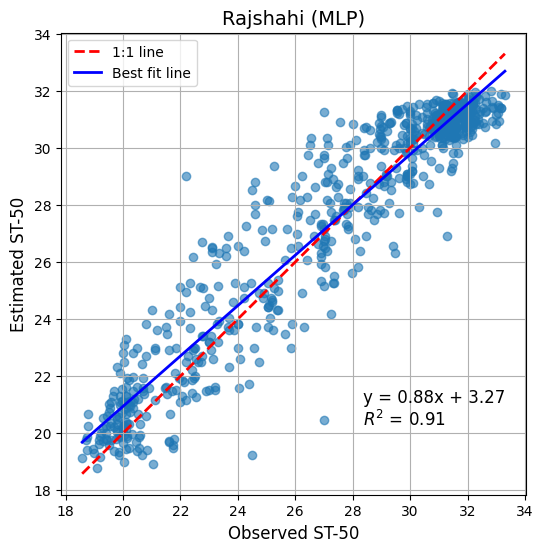

In [13]:


plt.figure(figsize=(6,6))
plt.scatter(y_val_raj, y_raj_pred, alpha=0.6)
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r--', lw=2, label="1:1 line")

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line")

plt.text(0.65, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-50', fontsize=12)
plt.ylabel('Estimated ST-50', fontsize=12)
plt.title('Rajshahi (MLP)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


# Srimongal MLP 

In [14]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)
val_end_sri = math.floor(m * 0.90)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:val_end_sri]
test_sri = df_sri.iloc[val_end_sri:]


In [15]:
val_sri.shape

(803, 4)

In [16]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-50']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-50']]

X_test_sri = test_sri[['Temperature']]
y_test_sri = test_sri[['ST-50']]


In [17]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_11640\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [18]:

scaler_sri = StandardScaler()
X_train_sri_scaled = scaler_sri.fit_transform(X_train_sri)
X_val_sri_scaled = scaler_sri.transform(X_val_sri)


models = Sequential()
models.add(Dense(50, activation='relu', input_shape=(X_train_sri_scaled.shape[1],)))
models.add(BatchNormalization())
models.add(Dropout(0.2))
models.add(Dense(30, activation='relu'))
models.add(Dense(16, activation='relu'))
models.add(Dense(1, activation='linear'))  


opt = Adam(learning_rate=0.001)
models.compile(optimizer=opt, loss='mse', metrics=['mae'])


es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


history_sri = models.fit(
    X_train_sri_scaled, y_train_sri,
    validation_data=(X_val_sri_scaled, y_val_sri),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=0
)


y_sri_pred = models.predict(X_val_sri_scaled)

mae_sri=mean_absolute_error(y_val_sri,y_sri_pred)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
r2_sri=r2_score(y_val_sri,y_sri_pred)

26/26 [==============================] - 0s 1ms/step


In [19]:
print(mae_sri,mse_sri,r2_sri)

0.846725583076477 1.1471854448318481 0.9256436228752136


In [20]:
from sklearn.linear_model import LinearRegression

y_val_sri_reshaped = np.array(y_val_sri).reshape(-1, 1)
y_sri_pred_reshaped = np.array(y_sri_pred).reshape(-1, 1)

lin = LinearRegression()
lin.fit(y_val_sri_reshaped, y_sri_pred_reshaped)

m_sri = lin.coef_[0][0]    
c_sri = lin.intercept_[0]    


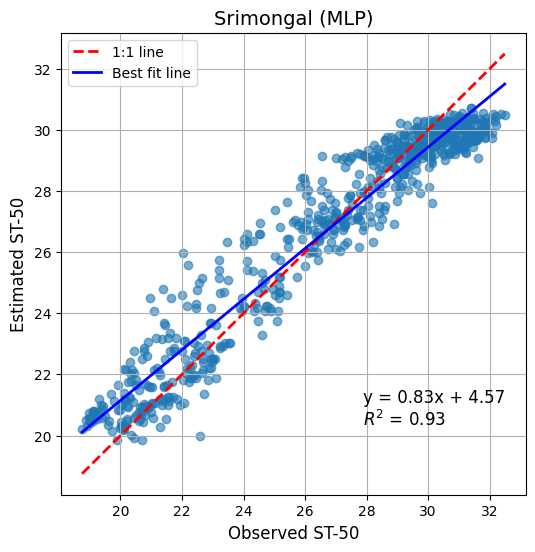

In [21]:


plt.figure(figsize=(6,6))
plt.scatter(y_val_sri, y_sri_pred, alpha=0.6)
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r--', lw=2, label="1:1 line")

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line")

plt.text(0.65, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-50', fontsize=12)
plt.ylabel('Estimated ST-50', fontsize=12)
plt.title('Srimongal (MLP)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
